# Building an Airline Support Agent with LangGraph and the Gemini API

This project implements a simulated airline support agent using LangGraph and the Gemini API. The agent is capable of searching for flights, booking flights (including handling travel class preferences), and canceling bookings.  It demonstrates the following Gen AI capabilities:

*   **Agents:** Core functionality is built around an intelligent agent orchestrating tasks.
*   **Function Calling:**  The agent utilizes function calling to interact with simulated airline APIs (search, book, cancel).
*   **Structured Output/JSON mode/Controlled generation:** The agent uses tools that return structured JSON, enabling precise data handling.
*   **Retrieval augmented generation (RAG):** Web search is used via DuckDuckGoSearchRun to find up to date airport codes.
*   **Long context window:** The agent uses gemini-1.5-flash-latest which has a 1M context window and can remember the conversations for much longer.

## Installing necessary libraries and packages

This below code imports necessary libraries and sets up the environment for the airline support agent. Core libraries include Langchain, LangGraph, and Google's Gemini API, enabling the agent's interaction with the simulated environment and the LLM. An IPython check ensures smooth package installation.

In [1]:
# -*- coding: utf-8 -*-
"""
Simulated Flight Booking and Cancellation Agent using LangGraph
"""

# Importing necessary packages and libraries

import os
import json
import random
import datetime
from typing import List, Dict, Annotated, Optional, Literal, Any
from typing_extensions import TypedDict
from pprint import pprint
import re 
import traceback 
import sys 
import string 

print(f"Python version: {sys.version}")
print("Installing necessary packages...")

# Use IPython magic only if available
try:
    import IPython
    shell = IPython.get_ipython()
    if shell:
        print("   Running in IPython environment, executing !pip install...")
        
        shell.run_line_magic('pip', "install langchain-community langchain-google-genai google-generativeai 'langgraph[draw]' requests pydantic duckduckgo-search --upgrade --quiet")
    else:
        print("   Not in IPython environment, skipping !pip install. Ensure packages are installed manually.")
except ImportError:
    print("   IPython not found, skipping !pip install. Ensure packages are installed manually.")
print("Installation attempt complete.")

# Import Core Libraries
try:
    import google.generativeai as genai
    from langchain_google_genai import ChatGoogleGenerativeAI
    from langchain_core.messages import BaseMessage, ToolMessage, AIMessage, HumanMessage, SystemMessage, AIMessageChunk
    from langchain_core.tools import Tool
    from langgraph.graph import StateGraph, START, END
    from langgraph.graph.message import add_messages
    from IPython.display import Image, display
    import requests
    from langchain_community.tools import DuckDuckGoSearchRun #for internet browsing capabilities
    print("Core libraries imported successfully.")
except ImportError as e:
    print(f"ERROR: Failed to import necessary libraries: {e}")
    sys.exit(1)

Python version: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
Installing necessary packages...
   Running in IPython environment, executing !pip install...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.9/433.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.2/145.2

## GOOGLE_API_KEY setting up

This code block securely retrieves the Google API key, prioritizing Kaggle Secrets or falling back to environment variables. It then configures the `genai` library for accessing the Gemini API. Proper error handling ensures robust API access.

In [2]:
# Attempt to import UserSecretsClient for Kaggle environments

UserSecretsClient = None
try:
    from kaggle_secrets import UserSecretsClient
    print("INFO: Kaggle UserSecretsClient imported.")
except ImportError:
    print("INFO: Kaggle UserSecretsClient not found. Will try environment variables.")

#API Key Setup
print("\n Setting up Google API Key...")
GOOGLE_API_KEY = None
if UserSecretsClient:
    try:
        user_secrets = UserSecretsClient()
        GOOGLE_API_KEY = user_secrets.get_secret("GOOGLE_API_KEY")
        print("Google API Key configured from Kaggle Secrets.")
    except Exception as e:
        print(f"Warning: Failed to get key from Kaggle Secrets: {e}. Trying environment variable.")
        GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
        if GOOGLE_API_KEY: print("Google API Key configured from environment variable (fallback).")
        else: print("ERROR: Google API Key not found in Kaggle Secrets or environment variables.")
else:
    print("INFO: Skipping Kaggle Secrets. Trying environment variable.")
    GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
    if GOOGLE_API_KEY: print("Google API Key configured from environment variable.")
    else: print("ERROR: Google API Key not found in environment variables.")

if GOOGLE_API_KEY:
    try:
        genai.configure(api_key=GOOGLE_API_KEY)
        os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
        print("genai library configured successfully.")
    except Exception as e:
        print(f"ERROR: Failed to configure genai library: {e}")
        GOOGLE_API_KEY = None
else:
    print("Warning: genai library not configured because API key was not found.")

if not GOOGLE_API_KEY:
    print("\n FATAL WARNING: GOOGLE_API_KEY is not set. The script will load but LLM calls will fail.")

INFO: Kaggle UserSecretsClient imported.

 Setting up Google API Key...
Google API Key configured from Kaggle Secrets.
genai library configured successfully.


## Simulated Flight System

This code block defines the simulated flight system, including functions for generating flight schedules with class-specific pricing (Economy and Business). It initializes in-memory data structures for flight schedules, search options, and bookings.

*   `_generate_flight_id(origin, dest)`: Generates a unique flight ID based on the origin and destination.
*   `_get_or_generate_daily_schedule(origin, destination, departure_date)`:  Generates or retrieves a list of flight schedules for a given route and date, including class-specific pricing (Economy/Business).
*   `search_flights_api(origin, destination, departure_date, passengers, return_date=None, travel_class="Economy")`: Simulates searching for flights with capacity checks, filtering results by travel class (Economy or Business) and storing search parameters for later booking.
*   `book_flight_api(flight_id, passenger_details)`: Simulates booking a flight, validating passenger details, using the selected flight ID and passenger information, and accounting for class-specific pricing.
*   `cancel_booking_api(booking_reference, passengers_to_cancel)`: Simulates cancelling tickets for specific passengers within a booking, calculating refunds based on the booked class fare, and updating or removing the booking as needed.
*   `_extract_passenger_details_from_text(text)`: Attempts to extract first name, last name, and gender from a text string, cleaning the input for better accuracy.
*   `_is_user_declining(text)`: Checks if a given text indicates that the user is declining or refusing something.
*   `_is_user_confirming(text)`: Checks if a given text indicates that the user is confirming or agreeing to something.
*   `_detect_modification_intent(text)`: Attempts to identify if the user intends to modify their search, specifically by detecting changes in the number of passengers.

In [3]:
# Onyx Air flight system & tool's logic

print("SIMULATED FLIGHT SYSTEM & TOOLS")

SIMULATED_SCHEDULE_CACHE: Dict[tuple, List[Dict[str, Any]]] = {}
LAST_SEARCH_OPTIONS: Dict[str, Dict[str, Any]] = {} # Will now store price based on selected class
BOOKINGS: Dict[str, Dict[str, Any]] = {} # Will now store booked class and its price
print("Initialized in-memory storage.")

def _generate_flight_id(origin, dest):
    return f"SIM{random.randint(100, 999)}{origin[:1].upper()}{dest[:1].upper()}"


def _get_or_generate_daily_schedule(origin: str, destination: str, departure_date: str) -> List[Dict[str, Any]]:
    """
    Generates or retrieves a consistent set of simulated flight definitions.
    NOW INCLUDES separate base prices for Economy and Business classes.
    """
    global SIMULATED_SCHEDULE_CACHE
    cache_key = (origin.upper(), destination.upper(), departure_date)
    if cache_key in SIMULATED_SCHEDULE_CACHE: return SIMULATED_SCHEDULE_CACHE[cache_key]
    daily_flights = []
    seed_str = f"{origin}-{destination}-{departure_date}"
    temp_random = random.Random(seed_str)
    for i in range(temp_random.randint(5, 10)):
        flight_id = _generate_flight_id(origin, destination)
        dep_hour = temp_random.randint(6, 19); duration_hours = temp_random.uniform(1.5, 6.0)
        dep_time_str = f"{dep_hour:02d}:{temp_random.choice(['00', '15', '30', '45'])}"
        try:
            dep_dt = datetime.datetime.strptime(f"{departure_date} {dep_time_str}", "%Y-%m-%d %H:%M")
            arr_dt = dep_dt + datetime.timedelta(hours=duration_hours)
            arr_time_str = arr_dt.strftime("%H:%M"); arr_date_str = arr_dt.strftime("%Y-%m-%d")
        except ValueError: continue

        # Generate Economy and Business prices
        base_price_economy = round(temp_random.uniform(90.0, 450.0), 2)
        
        # Business class is significantly more expensive
        business_multiplier = temp_random.uniform(1.8, 3.0)
        base_price_business = round(base_price_economy * business_multiplier, 2)

        capacity = temp_random.randint(5, 25) * 10 # Single capacity for simplicity
        
        airline = temp_random.choice(["SimAir", "CloudJet", "MockWing", "PixelAvia"])
        daily_flights.append({
            "id": flight_id, "airline": airline, "origin": origin, "destination": destination,
            "departure_date": departure_date, "departure_time": dep_time_str,
            "arrival_date": arr_date_str, "arrival_time": arr_time_str,
            "base_price_economy": base_price_economy, # Store Economy base price
            "base_price_business": base_price_business, # Store Business base price
            "capacity": capacity,
            "stops": temp_random.choice([0, 1]) })
    SIMULATED_SCHEDULE_CACHE[cache_key] = daily_flights
    print(f"   DEBUG (Schedule Gen): Generated {len(daily_flights)} flights for {cache_key} with Economy/Business prices.")
    return daily_flights


def search_flights_api(
    origin: str,
    destination: str,
    departure_date: str,
    passengers: int,
    return_date: Optional[str] = None,
    travel_class: Optional[str] = "Economy" # Added travel_class parameter
) -> str:
    """
    Simulates searching flights with capacity check FOR A SPECIFIC TRAVEL CLASS.
    Strictly requires 3-letter airport codes for origin and destination.
    Requires travel_class ('Economy' or 'Business', case-insensitive, defaults to Economy).
    Stores the selected class's base price per person in LAST_SEARCH_OPTIONS for booking/cancellation.
    """
    print(f"\n   --- TOOL CALL: search_flights (Strict Codes, Class Specific) ---")
    global LAST_SEARCH_OPTIONS
    LAST_SEARCH_OPTIONS = {} # Clear previous search options
    errors = []

    origin_code = origin.upper().strip() if isinstance(origin, str) else ""
    destination_code = destination.upper().strip() if isinstance(destination, str) else ""

    if len(origin_code) != 3 or not origin_code.isalpha(): errors.append(f"Invalid origin: '{origin}'. Must be a 3-letter airport code.")
    if len(destination_code) != 3 or not destination_code.isalpha(): errors.append(f"Invalid destination: '{destination}'. Must be a 3-letter airport code.")

    num_passengers = 0
    try:
        num_passengers = int(passengers)
        if num_passengers <= 0: errors.append("Passenger count must be > 0.")
    except (ValueError, TypeError): errors.append(f"Passenger count ('{passengers}') must be an integer.")

    if not departure_date: errors.append("Departure date required.")
    else:
        try: datetime.datetime.strptime(departure_date, '%Y-%m-%d')
        except ValueError: errors.append(f"Departure date '{departure_date}' format must be YYYY-MM-DD.")
    if return_date:
        try: datetime.datetime.strptime(return_date, '%Y-%m-%d')
        except ValueError: errors.append(f"Return date '{return_date}' format must be YYYY-MM-DD.")

    # Validate and normalize travel_class
    valid_classes = ["Economy", "Business"]
    selected_class = "Economy" # Default
    if travel_class and isinstance(travel_class, str):
        normalized_class = travel_class.strip().capitalize()
        if normalized_class in valid_classes:
            selected_class = normalized_class
        else:
             errors.append(f"Invalid travel_class: '{travel_class}'. Must be 'Economy' or 'Business'.")
    elif travel_class: # Handle case where it's provided but not a string (less likely via LLM tool call)
        errors.append(f"Invalid travel_class type: '{type(travel_class)}'. Must be a string ('Economy' or 'Business').")


    if errors:
        error_message = f"Invalid search parameters: {'; '.join(errors)}."
        print(f"   --- TOOL ERROR: search_flights - {error_message} ---")
        return json.dumps({"status": "error", "message": error_message})

    print(f"      Using Codes: {origin_code} -> {destination_code} on {departure_date}, Pax: {num_passengers}, Class: {selected_class}, Return: {return_date}")
    base_schedule = _get_or_generate_daily_schedule(origin_code, destination_code, departure_date)
    available_flights = []

    # Determine price key based on selected class
    base_price_key = f"base_price_{selected_class.lower()}" # e.g., 'base_price_economy'

    for flight_def in base_schedule:
        if flight_def.get("capacity", 0) >= num_passengers:
            # Get the base price for the selected class
            base_price_per_person_for_class = flight_def.get(base_price_key)
            if base_price_per_person_for_class is None:
                print(f"   WARN (Search): Missing price key '{base_price_key}' for flight {flight_def['id']}. Skipping.")
                continue

            price_total = round(base_price_per_person_for_class * num_passengers, 2)

            # Select fields for the result shown to user/LLM
            # Exclude capacity and the *other* class's base price
            excluded_keys = {"capacity", "base_price_economy", "base_price_business"}
            flight_result_display = { k: v for k, v in flight_def.items() if k not in excluded_keys }
            flight_result_display.update({
                "travel_class": selected_class, # Indicate the class searched for
                "price_per_person": base_price_per_person_for_class, # Price per person for this class
                "price_total": price_total, # Total price for this class
                "passengers": num_passengers
            })
            available_flights.append(flight_result_display)

            # Store the full result needed for booking (including capacity and THE base price for the searched class)
            search_option_cache = flight_def.copy()
            # Store the specific base price used for this search result and the selected class
            search_option_cache.update({
                "selected_class": selected_class,
                "base_price_per_person_booked": base_price_per_person_for_class,
                "price_total": price_total,
                "passengers": num_passengers
            })
            LAST_SEARCH_OPTIONS[flight_def["id"]] = search_option_cache

    print(f"   --- TOOL RESULT: search_flights - Found {len(available_flights)} {selected_class} flights with capacity. ---")
    if not available_flights:
        return json.dumps({
            "status": "not_found",
            "message": f"Sorry, no {selected_class} class flights found with enough capacity for {num_passengers} passengers from {origin_code} to {destination_code} on {departure_date}."
        })
    else:
        available_flights.sort(key=lambda x: x['price_total'])
        return json.dumps({"status": "found", "flights": available_flights})


def book_flight_api(flight_id: str, passenger_details: List[Dict[str, str]]) -> str:
    """
    Simulates booking a flight FOR THE CLASS SEARCHED.
    Requires per-passenger details including meal preference. Cleans passenger names.
    Checks against LAST_SEARCH_OPTIONS (which contains class-specific price info).
    Stores detailed passenger info, booked class, and the class-specific base price per person.
    Returns JSON confirmation including passenger names, Total price FOR THE BOOKED CLASS, or error.
    """
    print(f"\n   --- TOOL CALL: book_flight (Per-Pax Meal, Class Specific Price) ---")
    global BOOKINGS, LAST_SEARCH_OPTIONS

    errors = []
    if not isinstance(flight_id, str) or not flight_id: errors.append("flight_id (string) is required.")
    if not isinstance(passenger_details, list) or not passenger_details: errors.append("passenger_details (list of dicts with name/gender/meal_preference) is required.")
    if errors: return json.dumps({"status": "error", "message": f"Invalid booking parameters: {'; '.join(errors)}."})

    flight_id_upper = flight_id.upper()
    if flight_id_upper not in LAST_SEARCH_OPTIONS:
        print(f"   --- TOOL ERROR: book_flight - Flight ID '{flight_id}' not in LAST_SEARCH_OPTIONS. ---")
        return json.dumps({"status": "error", "message": f"Flight ID '{flight_id}' was not available or valid in the recent search. Please search again."})
    if any(b.get('flight_id', '').upper() == flight_id_upper for b in BOOKINGS.values()):
        print(f"   --- TOOL ERROR: book_flight - Flight ID '{flight_id}' already associated with a booking. ---")
        return json.dumps({"status": "error", "message": f"Flight ID '{flight_id}' appears already booked or processing."})

    flight_details_from_search = LAST_SEARCH_OPTIONS[flight_id_upper]
    expected_passengers = flight_details_from_search.get('passengers')
    booked_class = flight_details_from_search.get('selected_class') # Get the class from the search cache
    base_price_per_person_booked = flight_details_from_search.get('base_price_per_person_booked') # Get the class-specific price

    if len(passenger_details) != expected_passengers:
        return json.dumps({"status": "error", "message": f"Passenger count mismatch. Expected details for {expected_passengers}, received {len(passenger_details)}."})

    # Check if the necessary class-specific price is available
    if base_price_per_person_booked is None or booked_class is None:
        print(f"   --- TOOL ERROR: book_flight - Missing class-specific price or class info in cached search data for {flight_id_upper}. Cannot book. ---")
        return json.dumps({"status": "error", "message": "Internal error: Missing price/class information from search. Please try searching again."})

    # --- Passenger Detail Validation ---
    valid_passenger_list_for_booking = []
    passenger_errors = []
    meal_summary_list = []
    for i, pax in enumerate(passenger_details):
        pax_num = i + 1
        if not isinstance(pax, dict): passenger_errors.append(f"Passenger {pax_num} data not a dict."); continue
        required_keys = ['first_name', 'last_name', 'gender', 'meal_preference']
        missing_keys_strict = []
        if not pax.get('first_name'): missing_keys_strict.append('first_name')
        if not pax.get('last_name'): missing_keys_strict.append('last_name')
        if not pax.get('gender'): missing_keys_strict.append('gender')
        if pax.get('meal_preference') is None : missing_keys_strict.append('meal_preference')

        if missing_keys_strict: passenger_errors.append(f"Passenger {pax_num} missing/invalid: {', '.join(missing_keys_strict)}.")
        else:
            first = pax.get('first_name','').strip().rstrip(string.punctuation).strip().capitalize()
            last = pax.get('last_name','').strip().rstrip(string.punctuation).strip().capitalize()
            full_name = f"{first} {last}"
            gender = pax.get('gender', '').strip().capitalize()
            meal = pax.get('meal_preference', 'None').strip().capitalize()
            if gender not in ['Male', 'Female', 'Other']: gender = 'Unknown'
            if meal not in ['Vegetarian', 'Non-vegetarian', 'Non-Vegetarian', 'None']: meal = 'None'
            if meal == 'Non-vegetarian': meal = 'Non-Vegetarian'

            cleaned_details = {'first_name': first, 'last_name': last, 'full_name': full_name, 'gender': gender, 'meal_preference': meal}
            valid_passenger_list_for_booking.append(cleaned_details)
            meal_summary_list.append(meal)

    if passenger_errors: return json.dumps({"status": "error", "message": f"Invalid passenger details: {'; '.join(passenger_errors)}."})
    # --- End Passenger Detail Validation ---

    booking_ref = f"SIMBK{random.randint(1000, 9999)}"
    meal_counts = {pref: meal_summary_list.count(pref) for pref in set(meal_summary_list)}
    meal_pref_summary = ", ".join([f"{count} {pref}" for pref, count in meal_counts.items() if count > 0]) if any(c > 0 for c in meal_counts.values()) else "None specified"
    passenger_names_str = ", ".join([pax["full_name"] for pax in valid_passenger_list_for_booking])

    # Use the class-specific total price from the search cache
    final_total_price = flight_details_from_search['price_total']

    BOOKINGS[booking_ref] = {
        "booking_reference": booking_ref,
        "flight_id": flight_id_upper,
        "details": {
            "airline": flight_details_from_search.get('airline'),
            "origin": flight_details_from_search.get('origin'),
            "destination": flight_details_from_search.get('destination'),
            "departure_date": flight_details_from_search.get('departure_date'),
            "departure_time": flight_details_from_search.get('departure_time'),
            "arrival_date": flight_details_from_search.get('arrival_date'),
            "arrival_time": flight_details_from_search.get('arrival_time'),
            "booked_class": booked_class, # Store the booked class
            "base_price_per_person_at_booking": base_price_per_person_booked, # Store the specific base price
            "initial_passengers": expected_passengers,
            "current_passengers": expected_passengers,
            "current_total_price": final_total_price # Store the calculated total price
        },
        "passenger_info": valid_passenger_list_for_booking,
        "meal_preference_summary": meal_pref_summary,
        "booked_at": datetime.datetime.now().isoformat()
    }
    print(f"   --- TOOL RESULT: book_flight - Simulated {booked_class} class booking successful. Ref: {booking_ref} ---")

    # Confirmation message should mention the class
    confirmation_details = {
        "status": "confirmed",
        "booking_reference": booking_ref,
        "flight_summary": (
            f"{BOOKINGS[booking_ref]['details']['airline']} flight {flight_id_upper} "
            f"({booked_class} class) " # Mention class
            f"from {BOOKINGS[booking_ref]['details']['origin']} to {BOOKINGS[booking_ref]['details']['destination']} "
            f"on {BOOKINGS[booking_ref]['details']['departure_date']} at {BOOKINGS[booking_ref]['details']['departure_time']} "
            f"(arriving {BOOKINGS[booking_ref]['details']['arrival_date']} at {BOOKINGS[booking_ref]['details']['arrival_time']}) "
            f"for {expected_passengers} passengers ({passenger_names_str}). "
            f"Meal preferences: {meal_pref_summary}. "
            f"Total Price: ${final_total_price:.2f}" # Use the final total price
        )
    }
    return json.dumps(confirmation_details)



def cancel_booking_api(booking_reference: str, passengers_to_cancel: List[str]) -> str:
    """
    Simulates cancelling tickets for specific passengers within a booking.
    Requires booking_reference and list of FULL passenger names.
    Calculates refund based on the BASE PRICE PER PERSON FOR THE BOOKED CLASS.
    Removes specified passengers, recalculates price, and updates the booking.
    If all passengers are cancelled, the entire booking is removed.
    Returns detailed JSON status including refund information.
    """
    print(f"\n   --- TOOL CALL: cancel_booking (Partial Enabled, Class Specific Refund) ---")
    global BOOKINGS

    # --- Input Validation ---
    errors = []
    if not isinstance(booking_reference, str) or not booking_reference:
        errors.append("Invalid or missing booking_reference.")
    if not isinstance(passengers_to_cancel, list) or not passengers_to_cancel:
        errors.append("Missing or empty list of 'passengers_to_cancel' (full names).")
    elif not all(isinstance(name, str) and name.strip() for name in passengers_to_cancel):
        errors.append("List 'passengers_to_cancel' must contain non-empty strings (full names).")

    if errors:
        print(f"   --- TOOL ERROR: cancel_booking - Invalid input: {'; '.join(errors)} ---")
        return json.dumps({"status": "error", "message": f"Invalid cancellation parameters: {'; '.join(errors)}."})
    # --- End Input Validation ---

    ref_to_check = booking_reference.strip().upper()
    found_ref_key = next((key for key in BOOKINGS if key.upper() == ref_to_check), None)

    if not found_ref_key:
        print(f"   --- TOOL RESULT: cancel_booking - Ref '{booking_reference}' not found ---")
        return json.dumps({"status": "not_found", "reference": booking_reference, "message": "Booking reference not found."})

    booking_data = BOOKINGS[found_ref_key]
    current_passengers = booking_data.get("passenger_info", [])
    # Use the base price stored AT BOOKING time (which corresponds to the booked class)
    base_price_per_person_at_booking = booking_data.get("details", {}).get("base_price_per_person_at_booking")
    booked_class = booking_data.get("details", {}).get("booked_class", "Unknown") # Get class for context

    if base_price_per_person_at_booking is None:
         print(f"   --- TOOL ERROR: cancel_booking - Missing base price per person at booking in booking {found_ref_key}. Cannot process cancellation refund accurately. ---")
         return json.dumps({"status": "error", "reference": found_ref_key, "message": "Internal data error: Cannot calculate refund amount accurately. Please contact support."})

    # --- Passenger Finding Logic ---
    passengers_found_and_cancelled = []
    passengers_not_found = []
    remaining_passengers_info = list(current_passengers) # Work on a copy
    names_to_cancel_norm = {name.strip().lower() for name in passengers_to_cancel}
    indices_to_remove = []

    for i, pax_info in enumerate(current_passengers):
        pax_full_name_norm = pax_info.get('full_name', '').strip().lower()
        if pax_full_name_norm in names_to_cancel_norm:
            indices_to_remove.append(i)
            passengers_found_and_cancelled.append(pax_info.get('full_name', 'Unknown')) # Record original cleaned name
            names_to_cancel_norm.remove(pax_full_name_norm) # Remove found name to track not_found

    passengers_not_found = [name for name in passengers_to_cancel if name.strip().lower() in names_to_cancel_norm]

    if not passengers_found_and_cancelled:
        print(f"   --- TOOL RESULT: cancel_booking - None of the specified passengers found in {found_ref_key} ---")
        return json.dumps({
            "status": "no_action_taken", "reference": found_ref_key,
            "message": "No changes made. None of the specified passengers were found in this booking.",
            "passengers_not_found": passengers_to_cancel })

    indices_to_remove.sort(reverse=True)
    for index in indices_to_remove: del remaining_passengers_info[index]
    # --- End Passenger Finding Logic ---

    # Calculate Refund Amount using the base price PER PERSON FOR THE BOOKED CLASS
    refund_amount = round(base_price_per_person_at_booking * len(passengers_found_and_cancelled), 2)
    refund_message = f" A refund of ${refund_amount:.2f} (based on the {booked_class} class fare for the cancelled passengers) will be credited to your original payment method within 5-7 business days."

    # Update Booking or Delete if Empty
    if not remaining_passengers_info:
        del BOOKINGS[found_ref_key]
        print(f"   --- TOOL RESULT: cancel_booking - Success. Last passenger(s) cancelled for {found_ref_key}. Booking removed. ---")
        base_message = (
            f"Successfully cancelled {booked_class} class tickets for: {', '.join(passengers_found_and_cancelled)}. "
            f"Since these were the last passengers, the entire booking {found_ref_key} has been removed."
        )
        final_message = base_message + refund_message
        return json.dumps({
            "status": "fully_cancelled", "reference": found_ref_key, "message": final_message,
            "cancelled_passengers": passengers_found_and_cancelled, "passengers_not_found": passengers_not_found,
            "refund_amount": refund_amount })
    else:
        # Update the existing booking
        new_passenger_count = len(remaining_passengers_info)
        # Recalculate total price based on remaining passengers and the original class base price
        new_total_price = round(base_price_per_person_at_booking * new_passenger_count, 2)
        # --- Meal summary update ---
        new_meal_list = [pax.get('meal_preference', 'None') for pax in remaining_passengers_info]
        new_meal_counts = {pref: new_meal_list.count(pref) for pref in set(new_meal_list)}
        new_meal_pref_summary = ", ".join([f"{count} {pref}" for pref, count in new_meal_counts.items() if count > 0]) if any(c > 0 for c in new_meal_counts.values()) else "None specified"
        # --- End Meal summary update ---

        booking_data["passenger_info"] = remaining_passengers_info
        booking_data["details"]["current_passengers"] = new_passenger_count
        booking_data["details"]["current_total_price"] = new_total_price # Update total price
        booking_data["meal_preference_summary"] = new_meal_pref_summary
        booking_data["last_modified_at"] = datetime.datetime.now().isoformat()

        remaining_names = ", ".join([p.get('full_name', 'Unknown') for p in remaining_passengers_info])
        print(f"   --- TOOL RESULT: cancel_booking - Success. Partially cancelled {len(passengers_found_and_cancelled)} passenger(s) for {found_ref_key}. ---")

        base_message = (
            f"Successfully cancelled {booked_class} class tickets for: {', '.join(passengers_found_and_cancelled)}. "
            f"Booking {found_ref_key} now has {new_passenger_count} passengers remaining ({remaining_names}) in {booked_class} class. " # Mention class
            f"The adjusted total price is now ${new_total_price:.2f}."
            + (f" Note: Could not find passenger(s): {', '.join(passengers_not_found)}." if passengers_not_found else "")
        )
        final_message = base_message + refund_message
        return json.dumps({
            "status": "partially_cancelled", "reference": found_ref_key, "message": final_message,
            "cancelled_passengers": passengers_found_and_cancelled, "passengers_not_found": passengers_not_found,
            "refund_amount": refund_amount,
            "updated_booking_details": {
                "remaining_passengers_count": new_passenger_count, "remaining_passengers_names": remaining_names,
                "new_total_price": new_total_price, "booked_class": booked_class, # Include class in updated details
                "new_meal_summary": new_meal_pref_summary }
        })

print("Simulated backend functions updated for travel class (Economy/Business) and class-specific pricing/refunds.")


# Helper Functions
def _extract_passenger_details_from_text(text: str) -> Optional[Dict[str, str]]:
    """Attempts to extract First Name, Last Name, and Gender from user text. Cleans trailing punctuation."""
    details = {"first_name": None, "last_name": None, "gender": None}
    text_norm = text.strip(); text_lower = text_norm.lower()
    gender_match = re.search(r'\b(male|female|other|non-binary)\b', text_lower)
    if gender_match:
        gender_input = gender_match.group(1).capitalize()
        details["gender"] = 'Other' if gender_input == 'Non-binary' else gender_input
        text_norm = re.sub(r'\b' + gender_match.group(1) + r'\b', '', text_norm, flags=re.IGNORECASE).strip()

    # Try to handle simple names robustly and clean punctuation
    name_parts = [part.strip() for part in text_norm.split() if part.strip()] # Split by any whitespace
    if len(name_parts) >= 2:
        # Clean trailing punctuation from first and last parts of the name
        first_clean = name_parts[0].rstrip(string.punctuation).strip()
        # Join remaining parts for last name, cleaning the very last part
        last_parts_cleaned = [p for p in name_parts[1:-1]] 
        if len(name_parts) > 1: # Ensure there's at least one part for the last name
             last_parts_cleaned.append(name_parts[-1].rstrip(string.punctuation).strip())
        last_clean = " ".join(last_parts_cleaned)

        details["first_name"] = first_clean.capitalize()
        details["last_name"] = last_clean.capitalize()
    elif len(name_parts) == 1:
        # Clean trailing punctuation if only one name part given
        first_clean = name_parts[0].rstrip(string.punctuation).strip()
        details["first_name"] = first_clean.capitalize()
        # Last name will be missing, handled below

    if details.get("first_name") and details.get("last_name") and details.get("gender"):
        return details
    else:
        missing = [k for k in ["first_name", "last_name", "gender"] if not details.get(k)]
        print(f"   WARN (Extractor): FAILED - Missing: {missing}. Input: '{text}'")
        return None

def _is_user_declining(text: str) -> bool:
    text_lower = text.strip().lower()
    decline_words = ["no ", "nope", "nothing", "that's all", "not really", "don't ", "stop", "cancel that", "none"]
    if text_lower in ["no", "none"]: return True
    return any(word in text_lower for word in decline_words)

def _is_user_confirming(text: str) -> bool:
    text_lower = text.strip().lower()
    return any(word in text_lower for word in ["yes", "ok", "okay", "proceed", "sure", "yep", "start", "ready", "confirm", "do it", "book it", "yea", "yeah"])

def _detect_modification_intent(text: str) -> Optional[Dict[str, Any]]:
    text_lower = text.lower()
    modification = {}
    pax_match = re.search(r'(\d+)\s*(passengers?|people|travelers?|tickets?)', text_lower)
    if pax_match:
        try:
            modification['passengers'] = int(pax_match.group(1))
            print(f"   DEBUG (Intent Detect): Modification detected: {modification}")
            return modification
        except ValueError: pass
    return None

print("Helper functions defined (incl name cleaning).")

SIMULATED FLIGHT SYSTEM & TOOLS
Initialized in-memory storage.
Simulated backend functions updated for travel class (Economy/Business) and class-specific pricing/refunds.
Helper functions defined (incl name cleaning).


## LangGraph Setup: Defining State and Tools

This section defines the data structures (state) and tools used by the LangGraph agent.

#### 1. State Definition: `FlightBookingState`

*   Defines the `FlightBookingState` TypedDict, which encapsulates all the information needed to track the conversation state, including messages, search parameters, flight search results, passenger details, booking references, and control flow flags. The `travel_class` field is included to manage travel class preferences.

#### 2. LangChain Tool Definitions

*   Defines the LangChain tools that the agent can use to interact with the simulated flight system: `search_flights`, `book_flight`, `cancel_booking`, and `web_search`. Each tool is created as a `Tool` object with a name, function (`func`), and a descriptive string that tells the LLM how and when to use it. The descriptions for `search_flights`, `book_flight`, and `cancel_booking` are updated to emphasize travel class handling.

In [4]:
# LangGraph setting up

print("\n LANGGRAPH SETUP")

# Define PassengerInfo TypedDict
class PassengerInfo(TypedDict):
    first_name: str 
    last_name: str 
    full_name: str 
    gender: str
    meal_preference: Optional[str]

# Define State
class FlightBookingState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    # Search Params & Results
    origin: Optional[str]; destination: Optional[str]; departure_date: Optional[str]
    return_date: Optional[str]; passengers: Optional[int]
    travel_class: Optional[Literal['Economy', 'Business']] # ADDED: Store user's class preference
    flight_search_results: Optional[List[Dict[str, Any]]]; selected_flight_id: Optional[str]
    # Detail Collection State
    passenger_details: Optional[List[PassengerInfo]]
    collecting_passenger_number: Optional[int]
    needs_meal_for_current_pax: bool
    # Booking/Cancellation Outcome
    booking_reference: Optional[str]
    cancellation_reference: Optional[str]
    # Control Flow
    current_phase: Optional[Literal["search", "collect_details", "finalize", "cancel", "completed"]]
    finished: bool

print("State definition `FlightBookingState` updated with travel_class.")


# Define LangChain Tool Objects
web_search_tool = DuckDuckGoSearchRun()

tools = [
    Tool(
        name="search_flights", func=search_flights_api,
        description="Search for available flights based on specified criteria. Requires: origin (3-letter airport code), destination (3-letter airport code), departure_date (YYYY-MM-DD), passengers (int > 0). Optional: return_date (YYYY-MM-DD), travel_class (string: 'Economy' or 'Business', defaults to 'Economy' if not provided). Checks capacity and returns flight options with prices specific to the requested travel class.", # MODIFIED Description
        ),
    Tool(
        name="book_flight", func=book_flight_api,
        description="Books a flight for the CLASS searched, using the flight_id selected from search results. Requires: flight_id (string from search results), passenger_details (list of dictionaries, each MUST contain 'first_name', 'last_name', 'gender', and 'meal_preference' keys). Stores cleaned names and booked class info. Returns confirmation (including class and price) or error.", # MODIFIED Description
        ),
    Tool(
        name="cancel_booking", func=cancel_booking_api,
        description="Cancels tickets for specific passengers within a booking OR the entire booking. Requires: booking_reference (string) AND passengers_to_cancel (a LIST of full names, e.g., ['John Doe']). Calculates refund based on the original price paid for the BOOKED CLASS. Returns detailed status including cancellation summary, updated booking details (if partial), and class-specific refund info.", # MODIFIED Description
        ),
    Tool(
        name="web_search",
        func=web_search_tool.run,
        description="Use this tool to search the web for current information, like finding the 3-letter airport code for a specific city name when the user provides a city instead of a code."
    )
]
print(f"Defined {len(tools)} tools for LangChain (incl web search, updated descriptions for class).")


 LANGGRAPH SETUP
State definition `FlightBookingState` updated with travel_class.
Defined 4 tools for LangChain (incl web search, updated descriptions for class).


## System Prompt and Welcome Message

This section defines the system prompt that guides the LLM's behavior and the initial welcome message presented to the user.

#### 1. System Prompt (`FLIGHT_AGENT_SYSINT`)

*   Defines a `SystemMessage` containing detailed instructions for the LLM, outlining its role as a meticulous flight booking assistant, the workflow to follow (Search, Collect Details, Finalize Booking, Cancellation), the use of tools, and handling of travel class preferences, partial cancellation, and web search. The prompt emphasizes the importance of using 3-letter airport codes and clearly communicating class-specific pricing and refund information.

#### 2. Welcome Message (`WELCOME_MSG`)

*   Defines the initial welcome message displayed to the user, prompting them to indicate whether they want to book a flight or cancel/modify an existing booking.

In [5]:
FLIGHT_AGENT_SYSINT = SystemMessage(
    content="""You are a meticulous Flight Booking Assistant simulation using a structured process. Your goal is to help users find, book, or cancel flights, guiding them through distinct phases: Search, Collect Details, Finalize Booking, and Cancellation. You now have access to a web search tool, support PARTIAL CANCELLATION with refund information, and handle TRAVEL CLASS preferences (Economy/Business).
**Core Workflow & Rules:**

1.  **Greeting & Intent:** Greet the user. Determine if they want to Search/Book or Cancel. Set phase accordingly (`search` or `cancel`).  **If the user responds with a negative affirmation (e.g., "no", "nothing", "that's all", "nope", "not really"), immediately respond with "Alright. Thank you for choosing OnyxAir. Have a great day ahead! Happy and Safe Travels!" and set finished=True.  Do not transition to any other phase.**

2.  **Search Phase (`search`):**
    *   Collect required info: `origin`, `destination`, `departure_date` (YYYY-MM-DD), `passengers` (number > 0), and **`travel_class` ('Economy' or 'Business')**. Ask the user explicitly for their preferred class. Default to 'Economy' if they don't specify after being asked. Ask for `return_date` if needed.
    *   **Airport Codes:** The `search_flights` tool requires strict 3-letter airport codes (e.g., ZRH, LHR, CDG). If the user provides city names, use `web_search` first to find the code (e.g., "What is the main 3-letter airport code for Mumbai?"). Analyze the result to extract the code. If uncertain, ask the user.
    *   **Tool Call:** Only after you have 3-letter codes and all other details (including `travel_class`), call `search_flights`, passing the `travel_class` argument.
    *   **Present Results:** Present `search_flights` results clearly.  Display both the **'Per Person Fare'** and the **'Total Fare'** (for all passengers) in separate columns. The 'Total Fare' is for ALL passengers in the **requested travel class**. Mention the class when showing options (e.g., "Here are the available Business class flights..."). Ask user to select a `flight_id`.
    *   **Confirmation/Modification:** If user confirms a `flight_id` AND confirms readiness to book, transition to `collect_details`. If they want to modify search (e.g., different class, date), update parameters, potentially use `web_search`, call `search_flights` again, stay in `search` phase.
    *   If search fails or user doesn't select, guide them.

3.  **Collect Details Phase (`collect_details`):**
    *   Starts *only* after flight selected and user confirms booking readiness.
    *   Announce: "Okay, before confirming Flight [ID] ([Booked Class]) for [N] passengers, I need passenger details." (Mention the class).
    *   **First, I need the First Name, Last Name, and Gender for Passenger 1.**
    *   Collect sequentially for *each* passenger: Name/Gender, then Meal Preference.
    *   Use internal parsing. Re-prompt clearly if needed. Ensure First Name, Last Name, Gender are collected.
        *   **If the user responds with a negative affirmation (e.g., "no", "nothing", "that's all", "nope", "not really"), immediately respond with "Alright. Thank you for choosing OnyxAir. Have a great day ahead! Happy and Safe Travels!" and set finished=True.  Do not transition to any other phase.**
        *   If the extraction fails (missing information), then say: "I need a bit more information. Could you please provide the First Name, Last Name, and Gender for Passenger [X]?"
    *   Once details for *all* passengers collected, transition to `finalize`.
    *   If user cancels during this phase, return to `search` phase (clearing details).

4.  **Finalize Booking Phase (`finalize`):**
    *   Confirm readiness.
    *   Prepare and trigger `book_flight` tool call with `flight_id` and collected `passenger_details`. The tool uses the class associated with the `flight_id` from the search.

5.  **Tool Execution & Response Handling (Managed by graph):**
    *   `execute_tools_node` runs the tool.
    *   `chatbot_node` receives the tool result.
    *   **If `web_search`:** Extract needed info (airport code) and use it.
    *   **If `book_flight` succeeds:** Relay the confirmation in this EXACT format:
        "BOOKING CONFIRMED\n\n"
        "• Reference: {ref}\n"
        "• Flight: {flight_id} ({class})\n"
        "• Route: {origin} to {destination}\n"
        "• Date: {date}\n"
        "• Departure: {dep_time} | Arrival: {arr_time}\n"
        "• Passenger: {first_name} {last_name}\n"
        "• Meal: {meal_preference}\n"
        "• Total Price: {total_price}\n\n"
        "Is there anything else I can help you with today?"

        
        Where passenger_list shows each passenger as:
        "- {first_name} {last_name} (Meal: {meal_preference})"
    *   **If the user responds with a negative affirmation (e.g., "no", "nothing", "that's all", "nope", "not really", "no thanks", "no, thank you"), immediately respond with "Alright. Thank you for choosing OnyxAir. Have a great day ahead! Happy and Safe Travels!" and set finished=True.  Do not transition to any other phase.**
    *   If `book_flight` fails: Relay error politely. Transition back to `search`. **Respond with "We encountered an error booking the flight.  Let's try a new search, or Thank you for choosing OnyxAir! Have a great day ahead!", and set finished=True.**
    *   If `search_flights` succeeds/fails: Present results/inform user (handled in `search` phase logic, displaying 'Per Person Fare' and 'Total Fare').
    *   **If `cancel_booking` called:** The tool returns detailed JSON status. **Relay the main `message` clearly.** This message includes what happened (who was cancelled, who wasn't found, new price/pax count, if booking removed) AND **details about the refund calculated based on the original booked class fare.** Ask if anything else needed.

6.  **Cancellation Phase (`cancel`):**
    *   Ask for `booking_reference`.
    *   Ask "Which passenger(s) would you like to cancel tickets for? Please provide their FULL NAMES as booked. If cancelling all, say 'all passengers' or list all names."
    *   Formulate `passengers_to_cancel` list. *For now, assume you must get specific names.*
    *   Call `cancel_booking` tool.
    *   Relay the detailed result message from the tool (as described in point 5, including class-specific refund info).

7. General:

Be clear and polite. Use state info. Only call tools with required parameters.

If at any stage the user responds with a quit command ('q'/'quit') or responds with any negative affirmation (e.g., "no", "nothing", "that's all", "nope", "not really", "no thanks", "no, thank you", or similar):
Respond with the closing message once user says "no": "Thank you for choosing OnyxAir! Have a great day ahead!"
sys.exit(0)  # Hard termination - closes input channel
"""
)
WELCOME_MSG = "Hello! Welcome to OnyxAir! How may I assist with your travel plans today? Would you like to book a flight or cancel/modify an existing booking? (Type 'q' or 'quit' to exit)"
print("System prompt and welcome message updated for travel class, automatic quit, dual-price display, and collect_details intro/re-prompt.")

System prompt and welcome message updated for travel class, automatic quit, dual-price display, and collect_details intro/re-prompt.


## LLM Initialization

This section initializes the Language Model (LLM) from Google's Gemini API and binds the defined tools to it, enabling the agent to use these tools during conversation.

#### 1. LLM Initialization (`llm`)

*   If the `GOOGLE_API_KEY` is available, this code attempts to initialize a `ChatGoogleGenerativeAI` object using the `gemini-1.5-flash-latest` model. The `temperature` parameter is set to 0.2 for controlled generation, and `convert_system_message_to_human` is set to `True`.  If the API key is missing or initialization fails, the `llm` variable remains `None`.

#### 2. Tool Binding (`llm_with_tools`)

*   If the LLM initialization is successful, this code binds the defined tools to the LLM using `llm.bind_tools(tools)`.  This creates `llm_with_tools`, which is the LLM object that can actually call the defined tools. If the API key is missing or initialization fails, `llm_with_tools` variable remains `None`.

In [6]:
# Initialize LLM
llm = None
llm_with_tools = None
if GOOGLE_API_KEY:
    try:
        llm = ChatGoogleGenerativeAI(model="models/gemini-1.5-flash-latest", temperature=0.2, convert_system_message_to_human=True)
        llm_with_tools = llm.bind_tools(tools)
        print("LLM initialized and tools bound.")
    except Exception as e: print(f"ERROR: Failed to initialize LLM: {e}")
else: print("LLM not initialized (API key missing).")

LLM initialized and tools bound.


## Defining Nodes

### Core LangGraph Nodes

- `chatbot_node`: Main controller handling search, booking, cancellation flows with LLM integration.  
- `collect_details_node`: Sequentially collects passenger details and meal preferences.  
- `finalize_booking_node`: Validates and prepares flight booking tool call with cleaned passenger data.  
- `human_input_node`: Gets and processes user input with quit/decline handling.  
- `execute_tools_node`: Executes and validates tools (search/book/cancel flights, web search).


Key features:
- Maintains travel class context throughout booking flow  
- Uses cleaned passenger names for consistency  
- Handles meal preferences per passenger  
- Robust error handling and state validation

In [7]:
# Define Nodes

# Chatbot Node
def chatbot_node(state: FlightBookingState) -> Dict[str, Any]:
    """Handles search (incl class), cancellation intent, presents results (incl class), processes tool outcomes."""
    node_name = "Chatbot Node"; print(f"\n--- {node_name} (Phase: {state.get('current_phase', 'None')}) ---")
    current_messages = state["messages"]; state_update = {}

    if not llm_with_tools: return {"messages": [AIMessage(content="Language model unavailable.")], "finished": True, "current_phase": "completed"}

    # Initial Turn or Reset
    if not current_messages or state.get("current_phase") is None:
         print(f"   DEBUG ({node_name}): First turn or reset state."); state_update["current_phase"] = "search"
         state_update.update({
             "origin": None, "destination": None, "departure_date": None, "return_date": None,
             "passengers": None, "travel_class": None, # Reset travel_class
             "flight_search_results": None, "selected_flight_id": None,
             "passenger_details": [], "collecting_passenger_number": None,
             "needs_meal_for_current_pax": False, "booking_reference": None,
             "cancellation_reference": None
         })
         new_messages = [AIMessage(content=WELCOME_MSG)]
         initial_state = {key: state_update.get(key) if key != "messages" else [] for key in FlightBookingState.__annotations__}
         initial_state["messages"] = add_messages(current_messages, new_messages)
         initial_state["current_phase"] = state_update["current_phase"]
         initial_state["finished"] = False
         for key, value in state_update.items():
             if key != "messages": initial_state[key] = value
         return initial_state

    last_message = current_messages[-1]
    ai_response = None

    # Process Tool Results
    if isinstance(last_message, ToolMessage):
        print(f"   DEBUG ({node_name}): Processing ToolMessage from '{last_message.name}'")
        tool_result_content = last_message.content; tool_name = last_message.name; tool_call_id = last_message.tool_call_id

        if tool_name == "web_search":
            print(f"   DEBUG ({node_name}): Received web_search result. LLM will process.")
            pass # Fall through to invoke LLM
        else:
            try:
                tool_result = json.loads(tool_result_content) if isinstance(tool_result_content, str) else tool_result_content
                tool_status = tool_result.get("status"); tool_message = tool_result.get("message", "No message provided.")

                if tool_name == "search_flights":
                    state_update["current_phase"] = "search"
                    if tool_status == "found":
                        print(f"   DEBUG ({node_name}): Search successful."); state_update["flight_search_results"] = tool_result.get("flights",[])
                        # Retrieve original args to store context
                        original_tool_call = next((m.tool_calls[0] for m in reversed(current_messages[:-1]) if isinstance(m, AIMessage) and m.tool_calls and m.tool_calls[0].get('id') == tool_call_id), None)
                        if original_tool_call and original_tool_call.get('args'):
                            args = original_tool_call['args']; pax = args.get("passengers"); pax_int = None; tc = args.get("travel_class")
                            try:
                                if pax is not None: pax_int = int(float(pax))
                            except (ValueError, TypeError): pass
                            # Normalize retrieved travel class for state consistency
                            normalized_tc = None
                            if isinstance(tc, str):
                                normalized_tc = tc.strip().capitalize()
                                if normalized_tc not in ['Economy', 'Business']: normalized_tc = None # Invalidate if not expected

                            state_update["origin"]=args.get("origin"); state_update["destination"]=args.get("destination"); state_update["departure_date"]=args.get("departure_date"); state_update["return_date"]=args.get("return_date"); state_update["passengers"]=pax_int
                            state_update["travel_class"] = normalized_tc # Store the class used in the search

                            print(f"   DEBUG ({node_name}): Stored search context: O={state_update.get('origin')} D={state_update.get('destination')} Date={state_update.get('departure_date')} Pax={state_update.get('passengers')} Class={state_update.get('travel_class')}")
                        else: print(f"   WARN ({node_name}): Could not find original search args.")
                    else:
                        print(f"   DEBUG ({node_name}): Search failed/not found ({tool_status})."); state_update["flight_search_results"] = None
                        ai_response = f"Search Result: {tool_message}" # LLM will also be invoked based on this
                    state_update["selected_flight_id"] = None # Clear selection on new search results

                elif tool_name == "book_flight":
                    if tool_status == "confirmed":
                        booked_ref = tool_result.get('booking_reference')
                        print(f"   DEBUG ({node_name}): Booking confirmed. Ref: {booked_ref}")
                        state_update["booking_reference"] = booked_ref
                        # Reset context after successful booking
                        state_update.update({
                            "origin":None,"destination":None,"departure_date":None,"return_date":None,
                            "passengers":None, "travel_class": None, # Reset class
                            "flight_search_results":None,"selected_flight_id":None,
                            "passenger_details":[],"collecting_passenger_number":None,
                            "needs_meal_for_current_pax": False, "cancellation_reference": None
                            })
                        state_update["current_phase"] = "completed"
                        confirmation_summary = tool_result.get('flight_summary','Booking confirmed.') # Summary now includes class
                        ai_response = (
                            f"Congratulations! Booking Confirmed.\n"
                            f"Ref: **{booked_ref}**\n"
                            f"Summary: {confirmation_summary}\n\n"
                            f"Is there anything else I can help you with today?"
                        )
                    else: # Booking failed
                        print(f"   DEBUG ({node_name}): Booking failed ({tool_status}). Message: {tool_message}")
                        state_update["current_phase"] = "search" # Go back to search
                        state_update.update({"passenger_details":[], "collecting_passenger_number":None, "needs_meal_for_current_pax": False, "selected_flight_id": None}) # Clear booking attempt state
                        ai_response = f"Apologies, the booking failed: {tool_message}. Let's look for flights again, perhaps try a different class or check the details." # LLM will also be invoked

                elif tool_name == "cancel_booking":
                    cancelled_ref = tool_result.get("reference")
                    print(f"   DEBUG ({node_name}): Cancellation result for {cancelled_ref} - Status: {tool_status}")
                    # Use the message directly from the tool (includes class-specific refund info)
                    ai_response = tool_message + "\n\nIs there anything else I can help you with today?"
                    if tool_status == "fully_cancelled":
                        state_update["cancellation_reference"] = cancelled_ref
                        if state.get("booking_reference") == cancelled_ref: state_update["booking_reference"] = None
                        state_update["current_phase"] = "completed"
                    elif tool_status == "partially_cancelled":
                         state_update["current_phase"] = "completed"
                    else: # not_found, no_action_taken, error
                         state_update["current_phase"] = "completed"

            except json.JSONDecodeError as e:
                 print(f"   WARN ({node_name}): JSON parse error in tool result for {tool_name}: {e}")
                 ai_response = f"Sorry, I received an unclear response from the system ({tool_name}). Please try again."
            except Exception as e:
                 print(f"   ERROR ({node_name}): Unexpected error processing tool result for {tool_name}: {e}")
                 traceback.print_exc()
                 ai_response = f"Sorry, an internal error occurred while processing the {tool_name} result. Please try again."

    # Handle User Input based on Phase
    elif isinstance(last_message, HumanMessage):
        user_text = last_message.content
        current_phase = state.get("current_phase")

        if current_phase == "search":
            print(f"   DEBUG ({node_name}): Processing user input in SEARCH phase.")
            # Check for flight ID selection
            selected_id = None
            possible_id = user_text.strip().upper()
            last_results = state.get("flight_search_results")
            if last_results and isinstance(last_results, list):
                valid_ids = {str(flight['id']).upper() for flight in last_results if isinstance(flight, dict) and 'id' in flight}
                if possible_id in valid_ids:
                    selected_id = possible_id
                    print(f"   DEBUG ({node_name}): User selected flight ID: {selected_id}")
                    state_update["selected_flight_id"] = selected_id
                    # LLM should confirm and ask about proceeding

            # Check for booking confirmation
            previously_selected = state.get("selected_flight_id")
            if previously_selected and _is_user_confirming(user_text):
                 print(f"   DEBUG ({node_name}): User confirmed proceeding with {previously_selected}. Transitioning to collect_details.")
                 state_update["current_phase"] = "collect_details"
                 state_update["passenger_details"] = []
                 state_update["collecting_passenger_number"] = 1
                 state_update["needs_meal_for_current_pax"] = False
                 return state_update # Go directly to collect_details node

            # Check for modification intent
            modification = _detect_modification_intent(user_text)
            if modification and 'passengers' in modification:
                 print(f"   DEBUG ({node_name}): User wants to change passengers to {modification['passengers']}. Re-searching needed.")
                 state_update['passengers'] = modification['passengers']
                 state_update['selected_flight_id'] = None
                 state_update['flight_search_results'] = None
                 # LLM will handle gathering potentially missing info (like class) and re-searching

            # Implicit: LLM will handle asking for class if missing based on system prompt

        elif current_phase == "cancel":
             print(f"   DEBUG ({node_name}): Processing user input in CANCEL phase.")
             # LLM handles asking/triggering tool

        elif current_phase == "completed":
             print(f"   DEBUG ({node_name}): Processing user input in COMPLETED phase.")
             if _is_user_declining(user_text):
                 print(f"   DEBUG ({node_name}): User declined further assistance.")
                 state_update["finished"] = True
                 ai_response = "Alright. Thank you for choosing OnyxAir. Have a great day ahead!"
                 state_update["messages"] = [AIMessage(content=ai_response)]
                 return state_update # End conversation
             else:
                 print(f"   DEBUG ({node_name}): User asked for something else. Resetting phase to search.")
                 state_update["current_phase"] = "search" # Reset phase
                 state_update["travel_class"] = None # Clear class preference for new search
                 # Let LLM handle new request

    # Default: Invoke LLM
    if not state_update.get("finished") and state_update.get("current_phase") != "collect_details" and not ai_response:
        messages_for_llm = list(current_messages)
        messages_for_llm_with_sys = [FLIGHT_AGENT_SYSINT] + messages_for_llm
        try:
            print(f"   DEBUG ({node_name}): Sending {len(messages_for_llm_with_sys)} messages to LLM for next step.")
            llm_response = llm_with_tools.invoke(messages_for_llm_with_sys)
            if isinstance(llm_response, AIMessage):
                if llm_response.tool_calls: print(f"   DEBUG ({node_name}): LLM generated tool calls: {[tc.get('name') for tc in llm_response.tool_calls]}")
                else: print(f"   DEBUG ({node_name}): LLM generated text response.")
                state_update["messages"] = [llm_response]
            else:
                print(f"   WARN ({node_name}): LLM did not return an AIMessage. Type: {type(llm_response)}")
                ai_response = "Sorry, I encountered an issue generating a response. Could you please repeat?"
                state_update["messages"] = [AIMessage(content=ai_response)]
        except Exception as e:
            print(f"ERROR ({node_name}): Error invoking LLM: {e}")
            traceback.print_exc()
            ai_response = f"Sorry, an error occurred while processing your request: {e}"
            state_update["messages"] = [AIMessage(content=ai_response)]

    if "messages" not in state_update and ai_response:
        state_update["messages"] = [AIMessage(content=ai_response)]
    elif "messages" not in state_update:
        pass

    return state_update

print("Chatbot node updated to handle class context storage.")
print("Other core graph nodes remain structurally the same.")


# Collect Details Node (Handles cleaned full_name)
def collect_details_node(state: FlightBookingState) -> Dict[str, Any]:
    """Manages sequential collection of passenger details (incl CLEANED full_name) AND meal preference."""
    node_name = "Collect Details Node"; print(f"\n--- {node_name} (Phase: {state.get('current_phase')}) ---")
    state_update: Dict[str, Any] = {"needs_meal_for_current_pax": False}
    current_messages = state["messages"]
    last_message = current_messages[-1] if current_messages else None

    total_passengers = state.get("passengers")
    passenger_details_list = list(state.get("passenger_details", []) or [])
    collecting_pax_num = state.get("collecting_passenger_number")
    selected_flight_id = state.get("selected_flight_id")
    is_collecting_meal = state.get("needs_meal_for_current_pax", False)

    # Initial State Validation
    if not total_passengers or not selected_flight_id or not collecting_pax_num:
        print(f"   ERROR ({node_name}): Missing critical state (TotalPax: {total_passengers}, FlightID: {selected_flight_id}, CollectPaxNum: {collecting_pax_num}). Returning to search.")
        state_update["current_phase"] = "search"
        state_update["messages"] = [AIMessage(content="Something went wrong with the booking context. Let's restart the search.")]
        state_update.update({"passenger_details": [], "collecting_passenger_number": None, "needs_meal_for_current_pax": False})
        return state_update

    ai_response = None # Prepare for AI response message

    # Handle User Input
    if isinstance(last_message, HumanMessage):
        user_text = last_message.content

        is_likely_meal_response = "preference" in (current_messages[-2].content.lower() if len(current_messages) > 1 and isinstance(current_messages[-2], AIMessage) else "")
        if _is_user_declining(user_text) and not is_likely_meal_response:
             print(f"   DEBUG ({node_name}): User indicated stopping detail collection.")
             state_update["current_phase"] = "search"
             state_update["messages"] = [AIMessage(content="Okay, cancelling the detail collection. We can search again or select a different flight if needed.")]
             state_update.update({"passenger_details":[], "collecting_passenger_number":None, "selected_flight_id": None, "needs_meal_for_current_pax": False})
             return state_update

        # Collecting meal preference?
        if is_collecting_meal and collecting_pax_num is not None and collecting_pax_num <= total_passengers:
            current_pax_index = collecting_pax_num - 1
            if current_pax_index < len(passenger_details_list):
                print(f"   DEBUG ({node_name}): Attempting to extract meal preference for Passenger {collecting_pax_num}.")
                meal_pref = "None" # Default
                pref_lower = user_text.lower().strip()
                if "non-veg" in pref_lower or "non veg" in pref_lower or "meat" in pref_lower: meal_pref = "Non-Vegetarian"
                elif "veg" in pref_lower: meal_pref = "Vegetarian"
                elif pref_lower == "none" or _is_user_declining(user_text): meal_pref = "None"

                updated_details_list = list(passenger_details_list)
                if isinstance(updated_details_list[current_pax_index], dict):
                    pax_info_copy = dict(updated_details_list[current_pax_index])
                    pax_info_copy['meal_preference'] = meal_pref
                    updated_details_list[current_pax_index] = pax_info_copy
                    state_update["passenger_details"] = updated_details_list
                    print(f"   DEBUG ({node_name}): Meal preference '{meal_pref}' recorded for Passenger {collecting_pax_num} ({pax_info_copy.get('full_name', '')}).")
                    state_update["needs_meal_for_current_pax"] = False # Meal done

                    # All passengers done?
                    if collecting_pax_num == total_passengers:
                        print(f"   DEBUG ({node_name}): All passenger details and meals collected ({len(updated_details_list)}/{total_passengers}). Transitioning to finalize.")
                        state_update["current_phase"] = "finalize"
                        return state_update # Finalize node takes over
                    else:
                        # Move to next passenger
                        next_pax_num = collecting_pax_num + 1
                        state_update["collecting_passenger_number"] = next_pax_num
                        ai_response = f"Thank you. Please provide **Passenger {next_pax_num}**: First Name, Last Name, and Gender."
                        print(f"   DEBUG ({node_name}): Asking for Passenger {next_pax_num} details.")
                else:
                     print(f"   ERROR ({node_name}): Passenger data at index {current_pax_index} is not a dict. Resetting.")
                     state_update["current_phase"] = "search"; state_update["messages"] = [AIMessage(content="Sorry, encountered an internal data issue. Let's restart the search.")]
                     state_update.update({"passenger_details": [], "collecting_passenger_number": None, "needs_meal_for_current_pax": False})
                     return state_update
            else:
                 print(f"   ERROR ({node_name}): State inconsistency trying to collect meal for Pax {collecting_pax_num}. List length {len(passenger_details_list)}. Resetting.")
                 state_update["current_phase"] = "search"; state_update["messages"] = [AIMessage(content="Sorry, something went wrong. Let's restart the search.")]
                 state_update.update({"passenger_details": [], "collecting_passenger_number": None, "needs_meal_for_current_pax": False})
                 return state_update

        # Collecting name/gender?
        elif not is_collecting_meal and collecting_pax_num is not None and collecting_pax_num <= total_passengers:
            print(f"   DEBUG ({node_name}): Attempting to extract Name/Gender for Passenger {collecting_pax_num}")
            extracted = _extract_passenger_details_from_text(user_text) # Uses cleaned extraction
            if extracted and extracted.get("first_name") and extracted.get("last_name") and extracted.get("gender"):
                # Successfully got cleaned name and gender
                full_name = f"{extracted['first_name']} {extracted['last_name']}" # Use cleaned names
                new_pax_info: PassengerInfo = {
                    "first_name": extracted["first_name"],
                    "last_name": extracted["last_name"],
                    "full_name": full_name, # Store cleaned full name
                    "gender": extracted["gender"],
                    "meal_preference": None
                }
                updated_details_list = list(passenger_details_list) + [new_pax_info]
                state_update["passenger_details"] = updated_details_list

                # Ask for meal preference
                state_update["needs_meal_for_current_pax"] = True
                # Use the potentially cleaned full_name in the prompt
                ai_response = f"Thank you for providing details for {full_name}. Now, please provide the meal preference for Passenger {collecting_pax_num} ({full_name}): (e.g., Vegetarian, Non-Vegetarian, or None)"
                print(f"   DEBUG ({node_name}): Got Name/Gender for Pax {collecting_pax_num}. Asking for their meal preference.")
            else:
                # Failed extraction
                ai_response = f"Sorry, I couldn't quite get all the details for Passenger {collecting_pax_num}. Please provide their **First Name, Last Name, and Gender** clearly."
                print(f"   DEBUG ({node_name}): Failed Name/Gender extraction Pax {collecting_pax_num}. Re-prompting.")
                state_update["needs_meal_for_current_pax"] = False

        else:
            # Unexpected input state
            print(f"   WARN ({node_name}): Received unexpected input '{user_text}' in state (PaxNum: {collecting_pax_num}, IsCollectingMeal: {is_collecting_meal}). Re-prompting based on state.")
            # Re-trigger appropriate prompt
            if collecting_pax_num is not None and collecting_pax_num <= total_passengers:
                 if is_collecting_meal:
                     current_pax_index = collecting_pax_num - 1
                     if current_pax_index < len(passenger_details_list) and isinstance(passenger_details_list[current_pax_index], dict):
                         pax_info = passenger_details_list[current_pax_index]
                         pax_name = pax_info.get('full_name', f"Passenger {collecting_pax_num}")
                         ai_response = f"Please provide meal preference for Passenger {collecting_pax_num} ({pax_name}): (e.g., Vegetarian, Non-Vegetarian, or None)"
                     else:
                         ai_response = f"Please provide **Passenger {collecting_pax_num}**: First Name, Last Name, and Gender."
                         state_update["needs_meal_for_current_pax"] = False
                 else:
                      ai_response = f"Please provide **Passenger {collecting_pax_num}**: First Name, Last Name, and Gender."
            else:
                 print(f"   ERROR ({node_name}): Invalid state during re-prompt. Resetting.")
                 state_update["current_phase"] = "search"; state_update["messages"] = [AIMessage(content="Sorry, something went wrong. Let's restart.")]
                 state_update.update({"passenger_details":[], "collecting_passenger_number":None, "needs_meal_for_current_pax": False}); return state_update

    # Initial Entry 
    elif collecting_pax_num == 1 and not passenger_details_list and not is_collecting_meal:
         print(f"   DEBUG ({node_name}): First entry into node. Prompting for Passenger 1 details.")
         ai_response = (f"Okay, I have Flight ID {selected_flight_id} selected for {total_passengers} passengers. "
                        f"Let's collect the details.\nPlease provide **Passenger 1**: First Name, Last Name, and Gender.")
         state_update["needs_meal_for_current_pax"] = False

    # Re-entry / No Input
    else:
        print(f"   DEBUG ({node_name}): Node re-entered or no user input. Re-prompting based on current state (PaxNum: {collecting_pax_num}, NeedsMeal: {is_collecting_meal}).")
        if collecting_pax_num is not None and collecting_pax_num <= total_passengers:
            if is_collecting_meal:
                 current_pax_index = collecting_pax_num - 1
                 if current_pax_index < len(passenger_details_list) and isinstance(passenger_details_list[current_pax_index], dict):
                     pax_info = passenger_details_list[current_pax_index]
                     pax_name = pax_info.get('full_name', f"Passenger {collecting_pax_num}") # Use potentially cleaned name
                     ai_response = f"Please provide meal preference for Passenger {collecting_pax_num} ({pax_name}): (e.g., Vegetarian, Non-Vegetarian, or None)"
                 else:
                     ai_response = f"Let's get the details for **Passenger {collecting_pax_num}**: First Name, Last Name, and Gender."
                     state_update["needs_meal_for_current_pax"] = False
            else:
                 ai_response = f"Please provide **Passenger {collecting_pax_num}**: First Name, Last Name, and Gender."
        else:
            print(f"   ERROR ({node_name}): Invalid state reached without user input. Returning to search.")
            state_update["current_phase"] = "search"
            state_update["messages"] = [AIMessage(content="Something went wrong during detail collection. Let's restart.")]
            state_update.update({"passenger_details":[], "collecting_passenger_number":None, "needs_meal_for_current_pax": False})
            return state_update

    # Finalize state update
    if ai_response:
        state_update["messages"] = [AIMessage(content=ai_response)]
    else:
        state_update["messages"] = []

    return state_update


# Finalize Booking Node (Uses cleaned names)
def finalize_booking_node(state: FlightBookingState) -> Dict[str, Any]:
    """Prepares and returns the AIMessage to call the book_flight tool after validation. Uses cleaned names."""
    node_name = "Finalize Booking Node"; print(f"\n--- {node_name} (Phase: {state.get('current_phase')}) ---")
    state_update = {}

    selected_flight_id = state.get("selected_flight_id")
    passenger_details = state.get("passenger_details") # Should contain cleaned names from collect_details
    total_passengers = state.get("passengers")

    # Validate State
    errors = []
    if not selected_flight_id: errors.append("Missing selected flight ID.")
    if not passenger_details: errors.append("Missing passenger details.")
    elif not isinstance(passenger_details, list): errors.append("Passenger details are not in the correct list format.")
    elif total_passengers and len(passenger_details) != total_passengers: errors.append(f"Passenger detail count mismatch (Expected {total_passengers}, Got {len(passenger_details)}).")
    elif passenger_details: # Check content
        for i, pax in enumerate(passenger_details):
             pax_num = i + 1
             if not isinstance(pax, dict): errors.append(f"Passenger {pax_num} data format is invalid."); break
             missing_keys = []
             if not pax.get('first_name'): missing_keys.append('first_name')
             if not pax.get('last_name'): missing_keys.append('last_name')
             if not pax.get('full_name'): missing_keys.append('full_name') # Check cleaned full_name
             if not pax.get('gender'): missing_keys.append('gender')
             if pax.get('meal_preference') is None: missing_keys.append('meal_preference')
             if missing_keys: errors.append(f"Passenger {pax_num} is missing required details: {', '.join(missing_keys)}."); break

    if errors:
        print(f"   ERROR ({node_name}): Validation failed: {'; '.join(errors)}. Returning to search.")
        state_update["current_phase"] = "search"
        state_update["messages"] = [AIMessage(content=f"Sorry, there was an issue before booking: {'; '.join(errors)}. Let's try gathering the details again, starting from the search.")]
        state_update.update({"passenger_details": [], "collecting_passenger_number": None, "needs_meal_for_current_pax": False})
        return state_update

    # Prepare Tool Call
    print(f"   DEBUG ({node_name}): Preparing 'book_flight' tool call with {len(passenger_details)} passenger details.")
    tool_call_args = {
        "flight_id": selected_flight_id,
        "passenger_details": passenger_details, # Pass the list with cleaned names
    }
    tool_call_id = f"tool_{random.randint(10000, 99999)}"
    book_tool_call_message = AIMessage(
        content="", tool_calls=[{"name": "book_flight", "args": tool_call_args,"id": tool_call_id}]
    )
    print(f"   DEBUG ({node_name}): Generated tool call message for 'book_flight'.")
    state_update["messages"] = [book_tool_call_message]
    return state_update

# Human Input Node
def human_input_node(state: FlightBookingState) -> Dict[str, Any]:
    """Gets input from the user."""
    node_name = "Human Input Node"; print(f"\n--- {node_name} ---")
    if state.get("finished", False):
        return {"messages": [], "finished": True}

    last_message = state["messages"][-1] if state["messages"] else None

    # Print Assistant's last message or action status
    if isinstance(last_message, AIMessage):
        if last_message.content and last_message.content.strip(): print(f"\nAssistant: {last_message.content}")
        elif last_message.tool_calls and not last_message.content: print("\nAssistant: (Thinking... Preparing action...)")
        elif not last_message.content and not last_message.tool_calls: print("\nAssistant: How may I proceed?")
    elif isinstance(last_message, ToolMessage):
         tool_name = last_message.name; tool_status = 'processed'
         try:
             if isinstance(last_message.content, str) and last_message.content.startswith('{'): tool_status = json.loads(last_message.content).get('status', 'processed')
         except: pass
         if tool_name != 'web_search' or 'error' in str(last_message.content).lower(): print(f"\nAssistant: (Completed action: {tool_name}, status: {tool_status}) How can I help further?")
         else: print("\nAssistant: Okay, what's next?")
    elif last_message is None or (isinstance(last_message, AIMessage) and last_message.content == WELCOME_MSG): pass
    else: print("\nAssistant: How may I proceed?")

    # Get user input
    user_input = input("You:  ")
    user_input_lower = user_input.lower().strip()

    # Check for quit commands or declining final prompt
    quit_commands = ["q", "quit", "exit", "stop", "goodbye", "bye" "no", "nothing else"]
    is_quitting = user_input_lower in quit_commands
    is_final_prompt = False
    current_phase = state.get("current_phase")
    if current_phase == "completed" and isinstance(last_message, AIMessage) and last_message.content: is_final_prompt = "anything else" in last_message.content.lower()

    if is_quitting or (is_final_prompt and _is_user_declining(user_input)):
        print(f"   DEBUG ({node_name}): User quit or declined further help.")
        final_msg = "Alright. Thank you for choosing OnyxAir. Have a great day ahead!"
        current_msgs = state.get('messages', [])
        final_messages = add_messages(current_msgs, [HumanMessage(content=user_input), AIMessage(content=final_msg)])
        return {"messages": final_messages, "finished": True, "current_phase": "completed"}

    # Return user input
    updates: Dict[str, Any] = {"messages": [HumanMessage(content=user_input)], "finished": False}

    # Tentatively set selected_flight_id if input matches
    possible_id = user_input.strip().upper()
    last_results = state.get("flight_search_results")
    if current_phase == "search" and last_results and isinstance(last_results, list):
        valid_ids = {str(flight['id']).upper() for flight in last_results if isinstance(flight, dict) and 'id' in flight}
        if possible_id in valid_ids:
            print(f"   DEBUG ({node_name}): User input matches flight ID: {possible_id}. Setting selected_flight_id tentatively.")
            updates["selected_flight_id"] = possible_id

    return updates


# Execute Tools Node
def execute_tools_node(state: FlightBookingState) -> Dict[str, Any]:
    """Executes tools based on the last AIMessage's tool_calls."""
    node_name = "Execute Tools Node"; print(f"\n--- {node_name} ---")
    last_message = state["messages"][-1] if state["messages"] else None
    state_update = {"messages": []}

    if not isinstance(last_message, AIMessage) or not last_message.tool_calls:
        print(f"   DEBUG ({node_name}): No tool calls found in last message.")
        return state_update

    tool_calls = last_message.tool_calls
    tool_messages: List[ToolMessage] = []
    print(f"   DEBUG ({node_name}): Found {len(tool_calls)} tool calls.")

    for call in tool_calls:
        tool_name = call.get("name"); tool_args = call.get("args", {}); tool_call_id = call.get("id")
        if not tool_call_id or not tool_name: print(f"   WARN ({node_name}): Invalid tool call structure. Skipping: {call}"); continue

        print(f"   DEBUG ({node_name}): Preparing execution for '{tool_name}' (ID: {tool_call_id}) with raw args: {tool_args}")
        result_content = json.dumps({"status": "error", "message": f"Tool '{tool_name}' execution failed internally."})

        try:
            tool_to_execute = next((t for t in tools if t.name == tool_name), None)
            if not tool_to_execute: raise ValueError(f"Tool '{tool_name}' is not defined or available.")

            # Argument Validation
            final_args = tool_args.copy()
            if tool_name == "search_flights":
                required = ["origin", "destination", "departure_date", "passengers"]
                missing = [r for r in required if r not in final_args or not final_args[r]]
                if missing: raise ValueError(f"Missing required arguments: {', '.join(missing)}")
                try:
                    if not isinstance(final_args.get("origin"), str) or len(final_args["origin"]) != 3: raise ValueError("Origin must be a 3-letter code.")
                    if not isinstance(final_args.get("destination"), str) or len(final_args["destination"]) != 3: raise ValueError("Destination must be a 3-letter code.")
                    final_args["passengers"] = int(float(final_args["passengers"]))
                    if final_args["passengers"] <= 0: raise ValueError("Passenger count must be positive.")
                except (ValueError, TypeError, KeyError) as e: raise ValueError(f"Invalid argument format: {e}")
            elif tool_name == "book_flight":
                if "flight_id" not in final_args or not final_args["flight_id"]: raise ValueError("Missing 'flight_id'.")
                if "passenger_details" not in final_args or not isinstance(final_args["passenger_details"], list) or not final_args["passenger_details"]: raise ValueError("'passenger_details' must be a non-empty list.")
            elif tool_name == "cancel_booking":
                if "booking_reference" not in final_args or not final_args["booking_reference"]: raise ValueError("Missing 'booking_reference'.")
                if "passengers_to_cancel" not in final_args or not isinstance(final_args["passengers_to_cancel"], list) or not final_args["passengers_to_cancel"]: raise ValueError("Missing required 'passengers_to_cancel' (list of full names).")
                if not all(isinstance(name, str) and name.strip() for name in final_args["passengers_to_cancel"]): raise ValueError("'passengers_to_cancel' must be a list of non-empty strings (full names).")
            elif tool_name == "web_search":
                query_arg = final_args.get("query") or final_args.get("input") or next((v for v in final_args.values() if isinstance(v, str)), None)
                if not query_arg or not isinstance(query_arg, str): raise ValueError("Missing or invalid 'query' argument for web_search.")
                final_args = {"query": query_arg}

            # Execute the Tool 
            print(f"   DEBUG ({node_name}): Calling '{tool_name}' with validated final args: {final_args}")
            if tool_name == "web_search": result_content = tool_to_execute.func(final_args["query"])
            else: result_content = tool_to_execute.func(**final_args)
            

            tool_messages.append(ToolMessage(content=str(result_content), tool_call_id=tool_call_id, name=tool_name))
            print(f"   DEBUG ({node_name}): Tool '{tool_name}' executed successfully.")

        except (TypeError, ValueError) as arg_err:
             print(f"ERROR ({node_name}): Argument validation error for '{tool_name}': {arg_err}")
             error_content = json.dumps({ "status": "error", "message": f"Failed tool call due to invalid arguments for {tool_name}: {arg_err}" })
             tool_messages.append(ToolMessage(content=error_content, tool_call_id=tool_call_id, name=tool_name))
        except Exception as e:
            print(f"ERROR ({node_name}): Unexpected system error executing tool '{tool_name}': {e}")
            traceback.print_exc()
            error_content = json.dumps({ "status": "error", "message": f"An unexpected system error occurred while trying to run {tool_name}: {e}" })
            tool_messages.append(ToolMessage(content=error_content, tool_call_id=tool_call_id, name=tool_name))

    state_update["messages"] = tool_messages
    print(f"   DEBUG ({node_name}): Returning {len(tool_messages)} tool messages.")
    return state_update

print("Core LangGraph nodes defined/refactored.")

Chatbot node updated to handle class context storage.
Other core graph nodes remain structurally the same.
Core LangGraph nodes defined/refactored.


## Conditional Edge Routing Logic

### Flow Control Functions

- `route_after_chatbot`: Routes to tools/details/finalize/human/END based on message type and phase.  
- `route_after_collect_details`: Progresses to finalize or returns to chatbot based on phase.  
- `route_after_finalize_booking`: Routes to execute tools or returns to chatbot.  
- `route_after_human`: Directs to collect_details or chatbot based on current phase.  
- `route_after_execute_tools`: Always returns to chatbot for next steps.


Key characteristics:
- State-driven flow control  
- Phase-aware transitions  
- Automatic tool execution handling  
- Conversation termination support

In [8]:
# Define Conditional Edges - Routing Logic defined

def route_after_chatbot(state: FlightBookingState) -> Literal["execute_tools", "collect_details", "finalize_booking", "human_input", END]:
    if state.get("finished", False): return END
    last_message = state["messages"][-1] if state["messages"] else None
    current_phase = state.get("current_phase")
    if isinstance(last_message, AIMessage) and last_message.tool_calls: return "execute_tools"
    if current_phase == "collect_details": return "collect_details"
    if current_phase == "finalize": return "finalize_booking"
    if current_phase == "completed": return "human_input"
    return "human_input"

def route_after_collect_details(state: FlightBookingState) -> Literal["finalize_booking", "chatbot", "human_input", END]:
    if state.get("finished", False): return END
    current_phase = state.get("current_phase")
    if current_phase == "finalize": return "finalize_booking"
    if current_phase == "search": return "chatbot"
    return "human_input"

def route_after_finalize_booking(state: FlightBookingState) -> Literal["execute_tools", "chatbot", END]:
     if state.get("finished", False): return END
     last_message = state["messages"][-1] if state["messages"] else None
     if isinstance(last_message, AIMessage) and last_message.tool_calls: return "execute_tools"
     return "chatbot"

def route_after_human(state: FlightBookingState) -> Literal["chatbot", "collect_details", END]:
    if state.get("finished", False): return END
    current_phase = state.get("current_phase")
    if current_phase == "collect_details": return "collect_details"
    return "chatbot"

def route_after_execute_tools(state: FlightBookingState) -> Literal["chatbot"]:
     return "chatbot"

print("Routing functions defined.")

Routing functions defined.


## Flight Booking State Machine

### Graph Construction

- **Nodes Added**: chatbot, human_input, execute_tools, collect_details, finalize_booking
- **Edge Logic**: 
  - START → chatbot_node
  - Conditional routing between all nodes based on conversation state
  - Automatic tool execution pipeline
  - Terminal END state support

Key Features:
- Fully connected state machine  
- Dynamic conversation flow control  
- Error-handled compilation  
- Visualizable execution paths  

In [9]:
# Build the Graph
print("   Building the LangGraph state machine...")
graph_builder = StateGraph(FlightBookingState)

graph_builder.add_node("chatbot_node", chatbot_node)
graph_builder.add_node("human_input_node", human_input_node)
graph_builder.add_node("execute_tools_node", execute_tools_node)
graph_builder.add_node("collect_details_node", collect_details_node)
graph_builder.add_node("finalize_booking_node", finalize_booking_node)
print("   Nodes added.")

graph_builder.add_edge(START, "chatbot_node")
graph_builder.add_conditional_edges("chatbot_node", route_after_chatbot, {"execute_tools": "execute_tools_node", "collect_details": "collect_details_node", "finalize_booking": "finalize_booking_node", "human_input": "human_input_node", END: END})
graph_builder.add_conditional_edges("collect_details_node", route_after_collect_details, {"finalize_booking": "finalize_booking_node", "chatbot": "chatbot_node", "human_input": "human_input_node", END: END})
graph_builder.add_conditional_edges("finalize_booking_node", route_after_finalize_booking, {"execute_tools": "execute_tools_node", "chatbot": "chatbot_node", END: END})
graph_builder.add_conditional_edges("human_input_node", route_after_human, {"chatbot": "chatbot_node", "collect_details": "collect_details_node", END: END})
graph_builder.add_conditional_edges("execute_tools_node", route_after_execute_tools, { "chatbot": "chatbot_node" })
print("   Edges defined.")

flight_agent_graph = None
try:
    flight_agent_graph = graph_builder.compile()
    print("LangGraph compiled.")
except Exception as e:
    print(f"ERROR compiling LangGraph: {e}")
    traceback.print_exc()

   Building the LangGraph state machine...
   Nodes added.
   Edges defined.
LangGraph compiled.


## Visualization of the graph

Visualizes the flight agent graph using Mermaid if available, handling IPython display and errors gracefully.



 Visualizing graph...


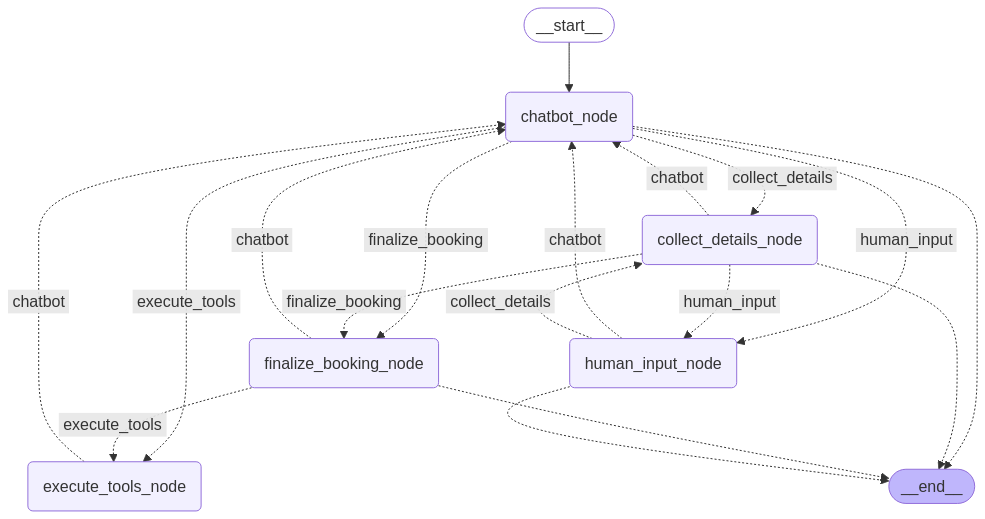



  Graph visualization displayed above.


In [10]:
# Visualize the graph
if flight_agent_graph:
    print("\n\n Visualizing graph...");
    try:
        graph_image = flight_agent_graph.get_graph().draw_mermaid_png()
        if 'IPython' in sys.modules: display(Image(graph_image)); print("\n\n  Graph visualization displayed above.")
        else: print("   (Skipping display - not in IPython environment.)")
    except Exception as e: print(f"Warning: Error generating graph visualization (may require graphviz): {e}.")
else: print("\n Cannot visualize graph (compilation failed).")

## Run the Onyx Airline AI Assistant

Initializes and runs the `flight_agent_graph` with user state, handling assistant interaction, session streaming, and graceful exit diagnostics.

In [11]:
# Run the Onyx Airline AI Assistant!

if flight_agent_graph and GOOGLE_API_KEY and llm:
    print("\n Starting Flight Booking Assistant Chat")
    print("   Type 'q', 'quit', 'exit', 'stop', 'goodbye' to end.")
    print("-" * 60); config = {"recursion_limit": 150}

    initial_state: FlightBookingState = {
        "messages": [],
        "origin": None, "destination": None, "departure_date": None, "return_date": None,
        "passengers": None,
        "travel_class": None, # Ensure travel_class is in the initial state
        "flight_search_results": None, "selected_flight_id": None,
        "passenger_details": [],
        "collecting_passenger_number": None,
        "needs_meal_for_current_pax": False,
        "booking_reference": None, "cancellation_reference": None,
        "current_phase": None,
        "finished": False
    }
    try:
        events = flight_agent_graph.stream(initial_state, config=config)
        final_state = None
        for event in events:
             if "__end__" in event:
                 potential_state_keys = ['__values__', 'final_state']
                 for key in potential_state_keys:
                      if key in event and isinstance(event[key], dict): final_state = event[key]; break
                 if not final_state: print("WARN: Could not extract final state from the end event structure.")

        print("\n" + "-" * 60); print("Chat Session Ended.")

        if final_state:
            # --- Final state analysis ---
            if final_state.get("finished"):
                last_ai_message_content = ""
                if final_state.get("messages") and isinstance(final_state["messages"][-1], AIMessage): last_ai_message_content = final_state["messages"][-1].content
                if "Have a great day ahead!" in last_ai_message_content:
                    print(f"\nAssistant: {last_ai_message_content}"); final_reason = "User quit or declined further assistance."
                elif final_state.get("cancellation_reference"): final_reason = f"Booking {final_state['cancellation_reference']} fully cancelled."
                elif final_state.get("booking_reference"): final_reason = f"Booking {final_state['booking_reference']} completed."
                else: final_reason = "Conversation finished by user request."
                print(f"   Reason: {final_reason}")
            elif not final_state.get("finished"):
                 print("   Reason: Graph execution limit reached or unexpected end.")
                 print(f"   Last Phase: {final_state.get('current_phase')}")
                 print(f"   Active Booking Ref: {final_state.get('booking_reference')}")
                 # Find last user message and last AI message for context
                 last_human = next((m.content for m in reversed(final_state.get('messages', [])) if isinstance(m, HumanMessage)), "None")
                 last_ai = next((m.content for m in reversed(final_state.get('messages', [])) if isinstance(m, AIMessage)), "None")
                 print(f"   Last User Msg: {last_human[:80]}...")
                 print(f"   Last AI Msg: {last_ai[:80]}...")
        elif not final_state and '__end__' not in event: print("   Reason: Stream ended prematurely or final state extraction failed.")
        else: print("   Reason: Unknown end state or final state unavailable.")


    except Exception as e:
        print(f"\n Error during graph execution/streaming:\n{traceback.format_exc()}")

elif not GOOGLE_API_KEY: print("\n Cannot start: GOOGLE_API_KEY missing/invalid.")
elif not llm: print("\n Cannot start: LLM failed initialization.")
else: print("\n Cannot start: LangGraph failed compilation.")


 Starting Flight Booking Assistant Chat
   Type 'q', 'quit', 'exit', 'stop', 'goodbye' to end.
------------------------------------------------------------

--- Chatbot Node (Phase: None) ---
   DEBUG (Chatbot Node): First turn or reset state.

--- Human Input Node ---

Assistant: Hello! Welcome to OnyxAir! How may I assist with your travel plans today? Would you like to book a flight or cancel/modify an existing booking? (Type 'q' or 'quit' to exit)

 Error during graph execution/streaming:
Traceback (most recent call last):
  File "/tmp/ipykernel_13/653783932.py", line 24, in <cell line: 0>
    for event in events:
  File "/usr/local/lib/python3.11/dist-packages/langgraph/pregel/__init__.py", line 2377, in stream
    for _ in runner.tick(
  File "/tmp/ipykernel_13/1462982146.py", line 452, in human_input_node
    user_input = input("You:  ")
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 1174, in raw_input
    raise St